### Notebook 2 — Meadowlark SLM + Allied Vision Camera

This notebook builds on the stable Meadowlark SLM control established in Notebook 1.

Goals:

1. Detect and connect the Allied Vision camera using the native `slmsuite` wrapper.
2. Acquire a static camera frame as a NumPy array.
3. Display camera images directly inside the Jupyter notebook.
4. Reconnect the Meadowlark SLM using the same stable initialization procedure.
5. Control the SLM and camera simultaneously from the same Python kernel.
6. Compare camera images for flat phase, horizontal blaze, reversed blaze, and vertical blaze.
7. Test repeated SLM update → camera acquisition cycles.
8. Finish with clean camera and SLM shutdown.

No GS, WGS, or Fourier calibration is performed in this notebook.

In [1]:
# Cell 1 — Imports and environment verification
# NO hardware access.

import sys
import time
import numpy as np
import matplotlib.pyplot as plt

from importlib.metadata import version

import slmsuite

from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.slms.meadowlark import Meadowlark

from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import blaze

print("=== Environment ===")
print("Python     :", sys.version.split()[0])
print("slmsuite  :", version("slmsuite"))
print("VmbPy     :", version("VmbPy"))
print("NumPy     :", version("numpy"))

print()
print("AlliedVision wrapper imported successfully.")
print("Meadowlark wrapper imported successfully.")

=== Environment ===
Python     : 3.12.10
slmsuite  : 0.4.1
VmbPy     : 1.2.2
NumPy     : 2.5.1

AlliedVision wrapper imported successfully.
Meadowlark wrapper imported successfully.


In [2]:
# Cell 2 — Detect and identify the physical Allied Vision camera
# This queries VmbPy but does NOT leave the camera open.

from vmbpy import VmbSystem

print("=== Allied Vision camera discovery ===\n")

camera_info = []

with VmbSystem.get_instance() as vmb:

    cameras = vmb.get_all_cameras()

    for cam_i in cameras:

        info = {
            "id":        cam_i.get_id(),
            "serial":    cam_i.get_serial(),
            "model":     cam_i.get_model(),
            "name":      cam_i.get_name(),
            "transport": cam_i.get_transport_layer().get_name(),
            "interface": cam_i.get_interface().get_name(),
        }

        camera_info.append(info)

        print(f"Camera {len(camera_info)}")
        print("  Serial    :", info["serial"])
        print("  Model     :", info["model"])
        print("  Transport :", info["transport"])
        print("  Interface :", info["interface"])
        print()


# Identify real USB cameras by excluding simulator transport layers.
physical_usb_cameras = [
    info for info in camera_info
    if "USB" in info["transport"].upper()
    and "SIMULATOR" not in info["transport"].upper()
]

print("=== Physical USB camera detection ===")

if len(physical_usb_cameras) == 1:

    physical_cam = physical_usb_cameras[0]

    CAMERA_SERIAL = physical_cam["serial"]

    print("Physical camera found!")
    print("Model  :", physical_cam["model"])
    print("Serial :", CAMERA_SERIAL)

elif len(physical_usb_cameras) == 0:

    raise RuntimeError(
        "No physical Allied Vision USB camera was detected."
    )

else:

    print("Multiple physical USB cameras detected:")

    for info in physical_usb_cameras:
        print(info["model"], "-", info["serial"])

    raise RuntimeError(
        "More than one physical USB camera is connected. "
        "Select the desired serial manually."
    )

=== Allied Vision camera discovery ===

Camera 1
  Serial    : 015C2
  Model     : 1800 U-2050m
  Transport : AVT USB Transport Layer
  Interface : AVT USB Interface

Camera 2
  Serial    : 0D512
  Model     : Camera Simulator (G1-030_VSWIR)
  Transport : Camera Simulator TL
  Interface : Camera Simulator Interface

Camera 3
  Serial    : 02775
  Model     : Camera Simulator (G1-510c)
  Transport : Camera Simulator TL
  Interface : Camera Simulator Interface

Camera 4
  Serial    : 0D4A9
  Model     : Camera Simulator
  Transport : Camera Simulator TL
  Interface : Camera Simulator Interface

=== Physical USB camera detection ===
Physical camera found!
Model  : 1800 U-2050m
Serial : 015C2


In [3]:
# Cell 3 — Connect to and verify the physical Allied Vision camera
# Opens the camera only if it is not already open.

if "cam" not in globals() or cam is None:

    print(f"Opening Allied Vision camera {CAMERA_SERIAL}...")

    cam = AlliedVision(
        serial=CAMERA_SERIAL,
        verbose=True,
    )

else:
    print("Camera object already exists.")
    print("Reusing the existing connection.")


# Verify that the existing/open camera is really the desired one.
try:
    detected_serial = cam.cam.get_serial()
    detected_model = cam.cam.get_model()

except Exception as exc:
    raise RuntimeError(
        "A camera object exists, but it does not appear to be usable. "
        "Restart the kernel and rerun Cells 1–3."
    ) from exc


if detected_serial != CAMERA_SERIAL:
    raise RuntimeError(
        f"Wrong camera is open: expected {CAMERA_SERIAL}, "
        f"but found {detected_serial}."
    )


print("\n=== Camera connected ===")
print("Name          :", cam.name)
print("Model         :", detected_model)
print("Serial        :", detected_serial)
print("Shape         :", cam.shape)
print("Default shape :", cam.default_shape)
print("Bit depth     :", cam.bitdepth)
print("dtype         :", cam.dtype)
print("Exposure      :", cam.exposure_s, "s")
print("WOI           :", cam.woi)
print("Pixel pitch   :", cam.pitch_um)

Opening Allied Vision camera 015C2...
vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success

=== Camera connected ===
Name          : 015C2
Model         : 1800 U-2050m
Serial        : 015C2
Shape         : (3672, 5496)
Default shape : (3672, 5496)
Bit depth     : 8
dtype         : uint8
Exposure      : 0.0050071809999999994 s
WOI           : (0, 5496, 0, 3672)
Pixel pitch   : None


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


Acquiring one frame...

=== Acquired image ===
Shape       : (3672, 5496)
dtype       : uint8
Min         : 0
Max         : 255
Mean        : 1.0614260361268881
Acquisition : 0.382 s


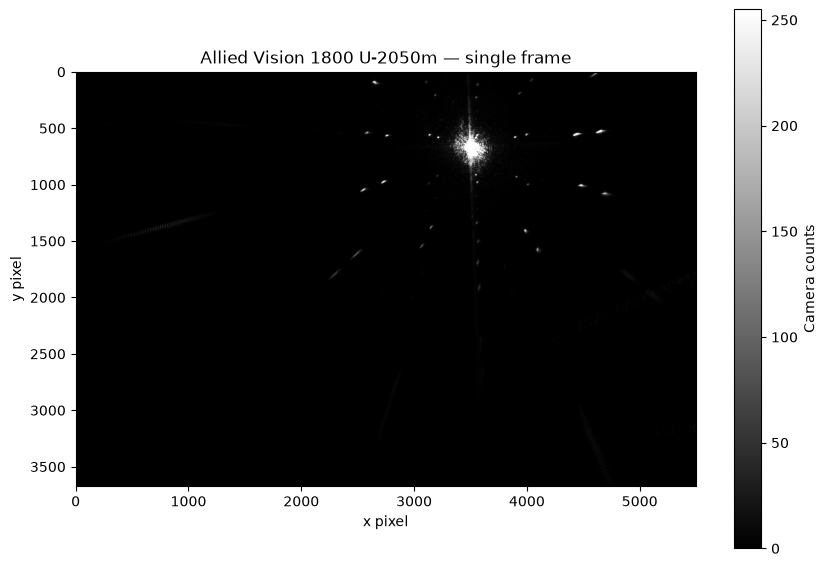

In [4]:
# Cell 4 — Acquire one static camera image

import time
import numpy as np
import matplotlib.pyplot as plt

print("Acquiring one frame...")

t0 = time.perf_counter()

image = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

print("\n=== Acquired image ===")
print("Shape       :", image.shape)
print("dtype       :", image.dtype)
print("Min         :", np.min(image))
print("Max         :", np.max(image))
print("Mean        :", np.mean(image))
print("Acquisition :", f"{dt:.3f} s")

plt.figure(figsize=(10, 7))

plt.imshow(
    image,
    cmap="gray",
    origin="upper",
)

plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Allied Vision 1800 U-2050m — single frame")

plt.show()

Current exposure : 5.007180999999999 ms
Requested exposure: 1.0 ms
Actual exposure   : 0.992181 ms

Acquiring frame...

=== Image statistics ===
Shape       : (3672, 5496)
Min         : 0
Max         : 255
Mean        : 0.2982275879784228
Saturated pixels: 7889
Saturated fraction: 0.039091 %
Acquisition time : 0.383 s


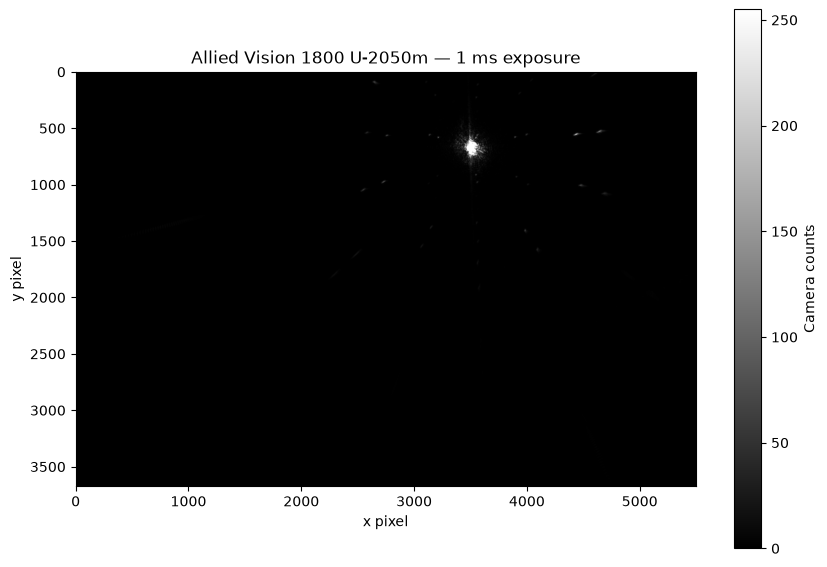

In [5]:
# Cell 5 — Reduce camera exposure and acquire another frame

import time
import numpy as np
import matplotlib.pyplot as plt

requested_exposure_s = 1e-3   # 1 ms

print("Current exposure :", cam.get_exposure() * 1e3, "ms")

actual_exposure_s = cam.set_exposure(requested_exposure_s)

print("Requested exposure:", requested_exposure_s * 1e3, "ms")
print("Actual exposure   :", actual_exposure_s * 1e3, "ms")

print("\nAcquiring frame...")

t0 = time.perf_counter()

image_1ms = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

# Saturation diagnostics
n_pixels = image_1ms.size
n_saturated = np.count_nonzero(image_1ms == 255)
sat_fraction = n_saturated / n_pixels

print("\n=== Image statistics ===")
print("Shape       :", image_1ms.shape)
print("Min         :", image_1ms.min())
print("Max         :", image_1ms.max())
print("Mean        :", image_1ms.mean())
print("Saturated pixels:", n_saturated)
print(f"Saturated fraction: {100*sat_fraction:.6f} %")
print(f"Acquisition time : {dt:.3f} s")

plt.figure(figsize=(10, 7))
plt.imshow(image_1ms, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Allied Vision 1800 U-2050m — 1 ms exposure")
plt.show()

Requested exposure : 0.1 ms
Actual exposure    : 0.112181 ms

Acquiring frame...

=== Image statistics ===
Shape            : (3672, 5496)
Min              : 0
Max              : 255
Mean             : 0.08245791948511573
Saturated pixels : 3149
Saturated fraction: 0.015604 %
Acquisition time  : 0.382 s


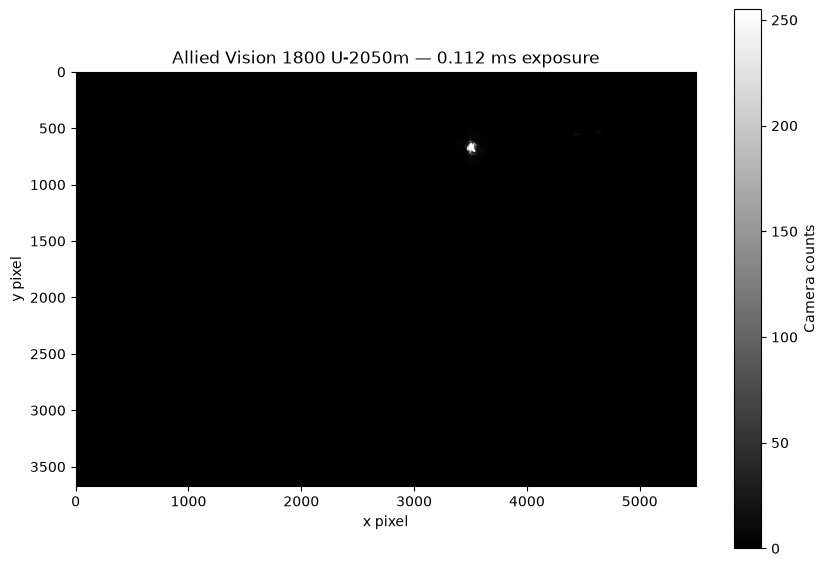

In [7]:
# Cell 6 — Test a shorter camera exposure

import time
import numpy as np
import matplotlib.pyplot as plt

requested_exposure_s = 0.1e-3   # 0.1 ms = 100 us

actual_exposure_s = cam.set_exposure(requested_exposure_s)

print("Requested exposure :", requested_exposure_s * 1e3, "ms")
print("Actual exposure    :", actual_exposure_s * 1e3, "ms")

print("\nAcquiring frame...")

t0 = time.perf_counter()

image_01ms = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

n_saturated = np.count_nonzero(image_01ms == 255)
sat_fraction = n_saturated / image_01ms.size

print("\n=== Image statistics ===")
print("Shape            :", image_01ms.shape)
print("Min              :", image_01ms.min())
print("Max              :", image_01ms.max())
print("Mean             :", image_01ms.mean())
print("Saturated pixels :", n_saturated)
print(f"Saturated fraction: {100*sat_fraction:.6f} %")
print(f"Acquisition time  : {dt:.3f} s")

plt.figure(figsize=(10, 7))
plt.imshow(image_01ms, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title(
    f"Allied Vision 1800 U-2050m — "
    f"{actual_exposure_s*1e3:.3f} ms exposure"
)
plt.show()

Requested exposure : 50.0 us
Actual exposure    : 57.181 us

Acquiring frame...

=== Image statistics ===
Shape             : (3672, 5496)
Min               : 0
Max               : 255
Mean              : 0.06366067775970165
Saturated pixels  : 2579
Saturated fraction: 0.012779 %
Acquisition time   : 0.382 s


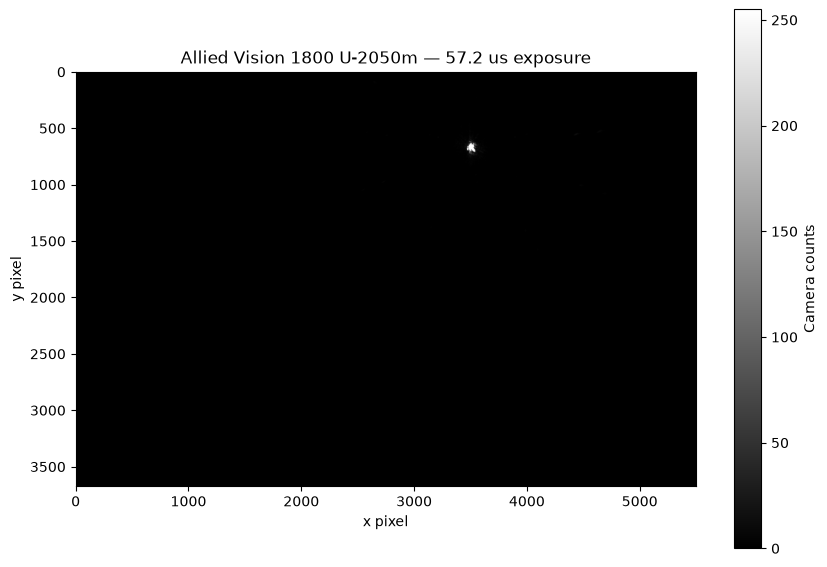

In [8]:
# Cell 7 — Test 50 us exposure

import time
import numpy as np
import matplotlib.pyplot as plt

requested_exposure_s = 50e-6   # 50 us

actual_exposure_s = cam.set_exposure(requested_exposure_s)

print("Requested exposure :", requested_exposure_s * 1e6, "us")
print("Actual exposure    :", actual_exposure_s * 1e6, "us")

print("\nAcquiring frame...")

t0 = time.perf_counter()

image_50us = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

n_saturated = np.count_nonzero(image_50us == 255)
sat_fraction = n_saturated / image_50us.size

print("\n=== Image statistics ===")
print("Shape             :", image_50us.shape)
print("Min               :", image_50us.min())
print("Max               :", image_50us.max())
print("Mean              :", image_50us.mean())
print("Saturated pixels  :", n_saturated)
print(f"Saturated fraction: {100*sat_fraction:.6f} %")
print(f"Acquisition time   : {dt:.3f} s")

plt.figure(figsize=(10, 7))
plt.imshow(image_50us, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title(
    f"Allied Vision 1800 U-2050m — "
    f"{actual_exposure_s*1e6:.1f} us exposure"
)
plt.show()

In [9]:
# Cell 8 — Inspect camera exposure limits and gain

print("=== Camera acquisition settings ===")

# Exposure
try:
    exp_us = cam.cam.ExposureTime.get()
    exp_range_us = cam.cam.ExposureTime.get_range()

    print("\nExposure:")
    print("Current :", exp_us, "us")
    print("Range   :", exp_range_us, "us")

except Exception as exc:
    print("\nCould not read ExposureTime:")
    print(exc)


# Gain
try:
    gain = cam.cam.Gain.get()
    gain_range = cam.cam.Gain.get_range()

    print("\nGain:")
    print("Current :", gain)
    print("Range   :", gain_range)

except Exception as exc:
    print("\nCould not read Gain:")
    print(exc)


# Auto gain
try:
    print("\nGainAuto :", cam.cam.GainAuto.get())
except Exception as exc:
    print("\nCould not read GainAuto:")
    print(exc)


# Auto exposure
try:
    print("ExposureAuto :", cam.cam.ExposureAuto.get())
except Exception as exc:
    print("Could not read ExposureAuto:")
    print(exc)

=== Camera acquisition settings ===

Exposure:
Current : 57.181 us
Range   : (29.681, 9999992.181) us

Gain:
Current : 0.0
Range   : (0.0, 27.000001907348633)

GainAuto : Off
ExposureAuto : Off


Requested exposure : 29.681 us
Actual exposure    : 29.681 us

Acquiring frame...

=== Image statistics ===
Shape             : (3672, 5496)
Min               : 0
Max               : 255
Mean              : 0.05150869279460126
Saturated pixels  : 2137
Saturated fraction: 0.010589 %
Acquisition time  : 0.380 s


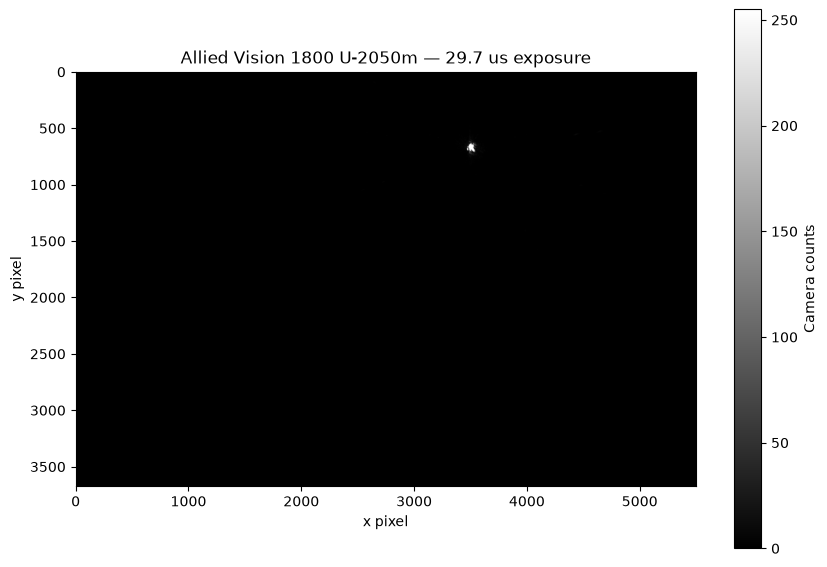

In [10]:
# Cell 9 — Test the minimum allowed camera exposure

import time
import numpy as np
import matplotlib.pyplot as plt

# Minimum reported by the camera
requested_exposure_s = 29.681e-6

actual_exposure_s = cam.set_exposure(requested_exposure_s)

print("Requested exposure :", requested_exposure_s * 1e6, "us")
print("Actual exposure    :", actual_exposure_s * 1e6, "us")

print("\nAcquiring frame...")

t0 = time.perf_counter()

image_minexp = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

n_saturated = np.count_nonzero(image_minexp == 255)
sat_fraction = n_saturated / image_minexp.size

print("\n=== Image statistics ===")
print("Shape             :", image_minexp.shape)
print("Min               :", image_minexp.min())
print("Max               :", image_minexp.max())
print("Mean              :", image_minexp.mean())
print("Saturated pixels  :", n_saturated)
print(f"Saturated fraction: {100*sat_fraction:.6f} %")
print(f"Acquisition time  : {dt:.3f} s")

plt.figure(figsize=(10, 7))
plt.imshow(image_minexp, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title(
    f"Allied Vision 1800 U-2050m — "
    f"{actual_exposure_s*1e6:.1f} us exposure"
)
plt.show()

Exposure : 194.681 us
Gain     : 0.0

=== Image statistics ===
Min               : 0
Max               : 201
Mean              : 0.0020111675593737412
Saturated pixels  : 0
Saturated fraction: 0.000000 %
Acquisition time  : 0.393 s


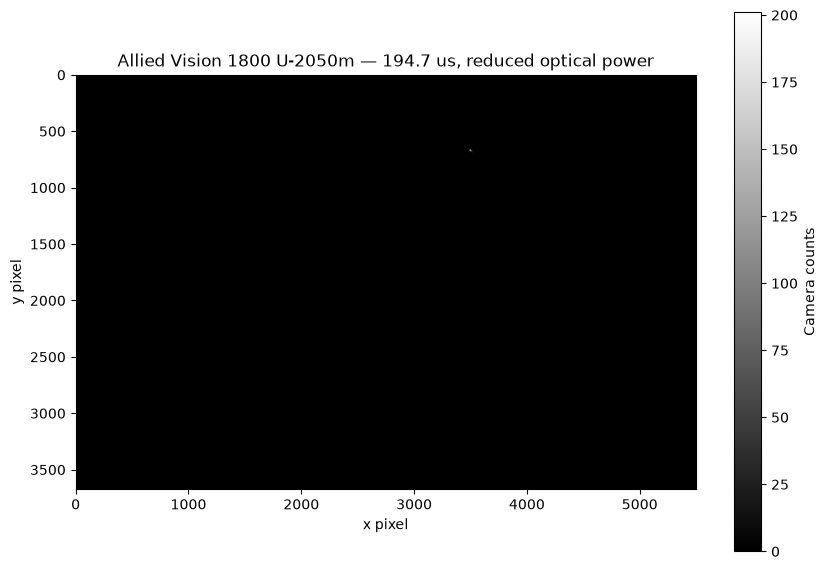

In [24]:
# Cell 10 — Check camera signal after reducing laser/AOM power

import numpy as np
import matplotlib.pyplot as plt
import time

# Use a comfortable exposure rather than the absolute minimum.
requested_exposure_s = 0.2e-3   # 0.2 ms

actual_exposure_s = cam.set_exposure(requested_exposure_s)

print("Exposure :", actual_exposure_s * 1e6, "us")
print("Gain     :", cam.cam.Gain.get())

t0 = time.perf_counter()

image_power_adjusted = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

n_saturated = np.count_nonzero(image_power_adjusted == 255)
sat_fraction = n_saturated / image_power_adjusted.size

print("\n=== Image statistics ===")
print("Min               :", image_power_adjusted.min())
print("Max               :", image_power_adjusted.max())
print("Mean              :", image_power_adjusted.mean())
print("Saturated pixels  :", n_saturated)
print(f"Saturated fraction: {100*sat_fraction:.6f} %")
print(f"Acquisition time  : {dt:.3f} s")

plt.figure(figsize=(10, 7))
plt.imshow(image_power_adjusted, cmap="gray", origin="upper")
plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title(
    f"Allied Vision 1800 U-2050m — "
    f"{actual_exposure_s*1e6:.1f} us, reduced optical power"
)
plt.show()

In [25]:
# Cell 11 — Define and verify Meadowlark SDK/LUT paths
# NO SLM hardware access yet.

from pathlib import Path

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\LUT from Fan\759nm_roomtemp_global"
    r"\759nm_roomtemp_global\759nm_rommtemp_global.lut"
)

SDK_DLL = SDK_PATH / "Blink_C_wrapper.dll"
SDK_HEADER = SDK_PATH / "Blink_C_wrapper.h"

print("=== Meadowlark path check ===")
print("SDK directory :", SDK_PATH)
print("SDK exists    :", SDK_PATH.exists())
print("DLL exists    :", SDK_DLL.exists())
print("Header exists :", SDK_HEADER.exists())

print()
print("LUT :", LUT_PATH)
print("LUT exists:", LUT_PATH.exists())

ready = (
    SDK_PATH.exists()
    and SDK_DLL.exists()
    and SDK_HEADER.exists()
    and LUT_PATH.exists()
)

print()
print("Ready for SLM initialization:", ready)

print("\n=== Camera still alive ===")
print("Camera :", cam.cam.get_model())
print("Serial :", cam.cam.get_serial())
print("Exposure:", cam.get_exposure() * 1e6, "us")

=== Meadowlark path check ===
SDK directory : C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK
SDK exists    : True
DLL exists    : True
Header exists : True

LUT : C:\Users\admin\Desktop\Projects\SLM\LUT from Fan\759nm_roomtemp_global\759nm_roomtemp_global\759nm_rommtemp_global.lut
LUT exists: True

Ready for SLM initialization: True

=== Camera still alive ===
Camera : 1800 U-2050m
Serial : 015C2
Exposure: 194.681 us


In [26]:
# Cell 12 — Initialize Meadowlark SLM while camera remains connected
# THIS CELL ACCESSES THE SLM HARDWARE.
#
# Run this ONCE per kernel session.

print("=== Before SLM initialization ===")
print("Camera model :", cam.cam.get_model())
print("Camera serial:", cam.cam.get_serial())

if "slm" in globals() and slm is not None:

    print("\nSLM object already exists.")
    print("NOT reconnecting to Meadowlark SDK.")

else:

    print("\nInitializing Meadowlark SLM...")

    slm = Meadowlark(
        slm_number=1,
        sdk_path=str(SDK_PATH),
        lut_path=str(LUT_PATH),
        wav_um=0.759,
        verbose=True,
    )

    print("\n=== SLM connected ===")
    print("Name       :", slm.name)
    print("Shape      :", slm.shape)
    print("Bit depth  :", slm.bitdepth)
    print("Wavelength :", slm.wav_um, "um")
    print("Pixel pitch:", slm.pitch_um, "um")


print("\n=== Camera after SLM initialization ===")
print("Camera model :", cam.cam.get_model())
print("Camera serial:", cam.cam.get_serial())
print("Exposure     :", cam.get_exposure() * 1e6, "us")

print("\nBoth hardware objects exist:")
print("cam :", cam is not None)
print("slm :", slm is not None)

=== Before SLM initialization ===
Camera model : 1800 U-2050m
Camera serial: 015C2

Initializing Meadowlark SLM...
Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM connected ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Bit depth  : 8
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um

=== Camera after SLM initialization ===
Camera model : 1800 U-2050m
Camera serial: 015C2
Exposure     : 194.681 us

Both hardware objects exist:
cam : True
slm : True


=== Combined SLM + camera test ===

Writing flat phase to SLM...
SLM write completed in 0.325 s

Acquiring camera frame...

=== Flat-phase camera image ===
Shape             : (3672, 5496)
dtype             : uint8
Min               : 0
Max               : 194
Mean              : 0.001988225542521715
Saturated pixels  : 0
Saturated fraction: 0.000000 %
Camera acquisition : 0.381 s

=== Hardware status ===
SLM    : Meadowlark HDMI
Camera : 1800 U-2050m
Serial : 015C2


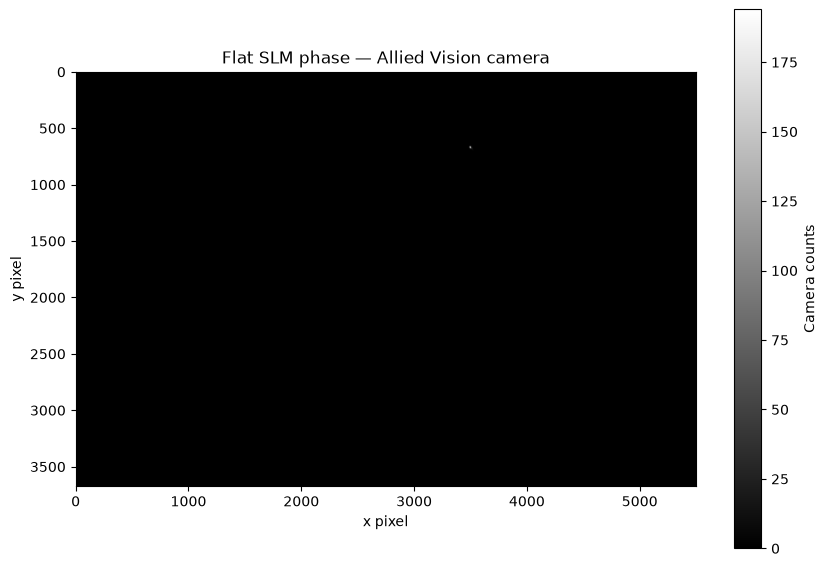

In [27]:
# Cell 13 — Write flat phase to SLM and acquire camera image
# BOTH SLM AND CAMERA ARE USED IN THIS CELL.

import time
import numpy as np
import matplotlib.pyplot as plt

print("=== Combined SLM + camera test ===")

# ------------------------------------------------------------
# 1. Explicitly write flat phase
# ------------------------------------------------------------

print("\nWriting flat phase to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    None,
    settle=True,
)

slm_time = time.perf_counter() - t0

print(f"SLM write completed in {slm_time:.3f} s")


# ------------------------------------------------------------
# 2. Acquire camera frame
# ------------------------------------------------------------

print("\nAcquiring camera frame...")

t0 = time.perf_counter()

image_flat = cam.get_image(timeout_s=2)

camera_time = time.perf_counter() - t0


# ------------------------------------------------------------
# 3. Image diagnostics
# ------------------------------------------------------------

n_saturated = np.count_nonzero(image_flat == 255)
sat_fraction = n_saturated / image_flat.size

print("\n=== Flat-phase camera image ===")
print("Shape             :", image_flat.shape)
print("dtype             :", image_flat.dtype)
print("Min               :", image_flat.min())
print("Max               :", image_flat.max())
print("Mean              :", image_flat.mean())
print("Saturated pixels  :", n_saturated)
print(f"Saturated fraction: {100*sat_fraction:.6f} %")
print(f"Camera acquisition : {camera_time:.3f} s")

print("\n=== Hardware status ===")
print("SLM    :", slm.name)
print("Camera :", cam.cam.get_model())
print("Serial :", cam.cam.get_serial())


# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(
    image_flat,
    cmap="gray",
    origin="upper",
)

plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Flat SLM phase — Allied Vision camera")

plt.show()

=== Horizontal blaze ===
Angle : 2.5 mrad
kxy   : (np.float64(0.0025), np.float64(0.0))

Writing blaze to SLM...
SLM write completed in 0.332 s

Acquiring camera frame...

=== Camera image ===
Shape             : (3672, 5496)
Min               : 0
Max               : 156
Mean              : 0.0019147912682782964
Saturated pixels  : 0
Camera acquisition : 0.377 s

=== Brightest-pixel position ===
Flat phase : x = 3499, y = 668
Blaze      : x = 3499, y = 666
Shift      : dx = 0 px, dy = -2 px


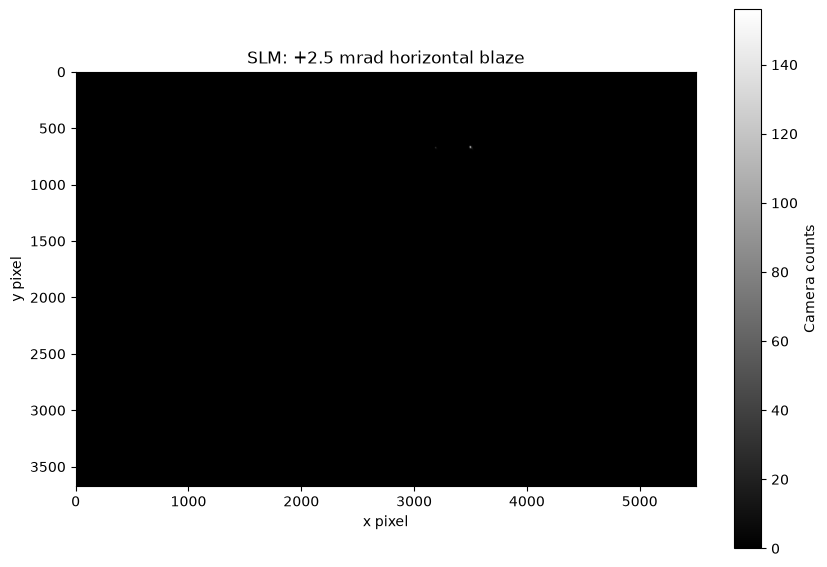

In [28]:
# Cell 14 — Apply horizontal blaze and acquire camera image
# BOTH SLM AND CAMERA ARE USED.

import time
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Generate 2.5 mrad horizontal blaze
# ------------------------------------------------------------

theta_x_mrad = 2.5

vector_x_kxy = tuple(
    np.ravel(
        convert_vector(
            (theta_x_mrad, 0.0),
            from_units="mrad",
            to_units="kxy",
            hardware=slm,
        )
    )
)

phase_blaze_x = blaze(
    grid=slm,
    vector=vector_x_kxy,
)

print("=== Horizontal blaze ===")
print("Angle :", theta_x_mrad, "mrad")
print("kxy   :", vector_x_kxy)


# ------------------------------------------------------------
# 2. Send blaze to SLM
# ------------------------------------------------------------

print("\nWriting blaze to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze_x,
    settle=True,
)

slm_time = time.perf_counter() - t0

print(f"SLM write completed in {slm_time:.3f} s")


# ------------------------------------------------------------
# 3. Acquire camera frame
# ------------------------------------------------------------

print("\nAcquiring camera frame...")

t0 = time.perf_counter()

image_blaze_x = cam.get_image(timeout_s=2)

camera_time = time.perf_counter() - t0


# ------------------------------------------------------------
# 4. Diagnostics
# ------------------------------------------------------------

n_saturated = np.count_nonzero(image_blaze_x == 255)

# Brightest pixel in flat image
flat_y, flat_x = np.unravel_index(
    np.argmax(image_flat),
    image_flat.shape
)

# Brightest pixel with blaze
blaze_y, blaze_x = np.unravel_index(
    np.argmax(image_blaze_x),
    image_blaze_x.shape
)

dx_pix = blaze_x - flat_x
dy_pix = blaze_y - flat_y

print("\n=== Camera image ===")
print("Shape             :", image_blaze_x.shape)
print("Min               :", image_blaze_x.min())
print("Max               :", image_blaze_x.max())
print("Mean              :", image_blaze_x.mean())
print("Saturated pixels  :", n_saturated)
print(f"Camera acquisition : {camera_time:.3f} s")

print("\n=== Brightest-pixel position ===")
print(f"Flat phase : x = {flat_x}, y = {flat_y}")
print(f"Blaze      : x = {blaze_x}, y = {blaze_y}")
print(f"Shift      : dx = {dx_pix} px, dy = {dy_pix} px")


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(
    image_blaze_x,
    cmap="gray",
    origin="upper",
)

plt.colorbar(label="Camera counts")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("SLM: +2.5 mrad horizontal blaze")

plt.show()

=== Expected blaze displacement ===
Expected physical shift : 750.0 um
Expected camera shift   : 312.5 pixels

Zero-order position:
x = 3499
y = 668

=== Candidate blazed order ===
x = 3192
y = 672
dx = -307 pixels
dy = +4 pixels
radius = 307.0 pixels

Physical displacement ≈ 736.8625380625616 um


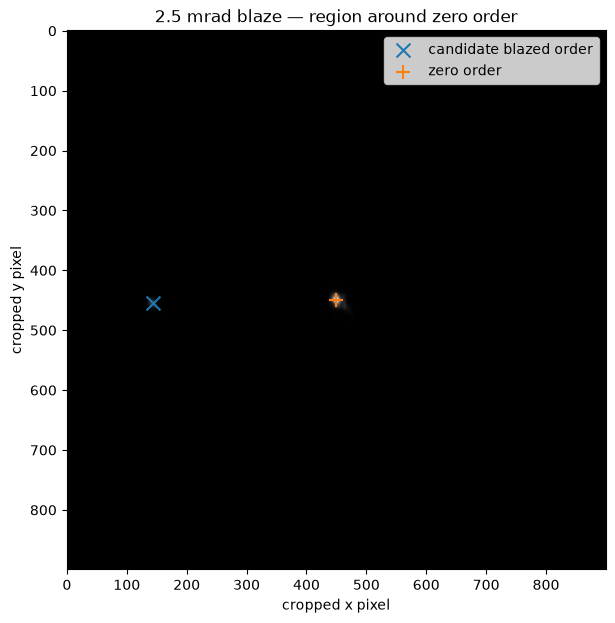

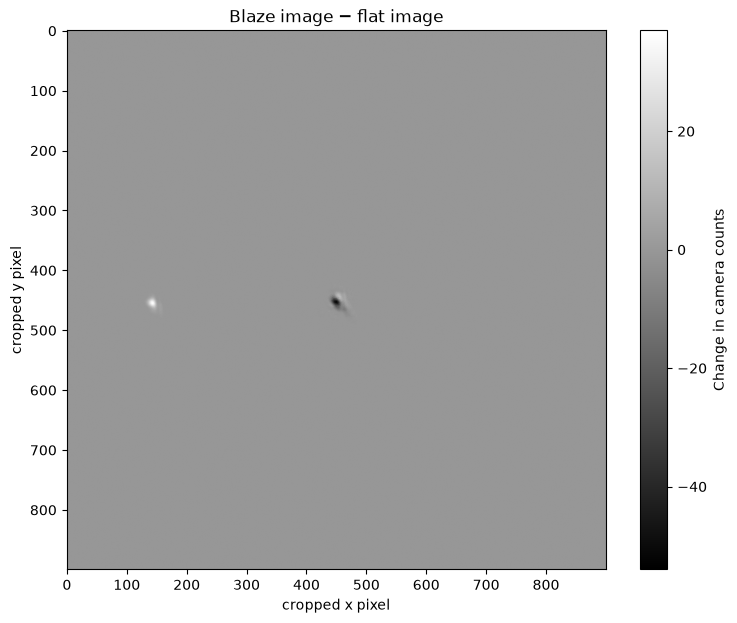

In [29]:
# Cell 15 — Locate the displaced first diffraction order
# Uses already-acquired flat and blaze images.
# NO new hardware write.

import numpy as np
import matplotlib.pyplot as plt

# Camera physical pixel size for Allied Vision 1800 U-2050m
camera_pitch_um = 2.40

# Expected displacement for 2.5 mrad at f = 300 mm
expected_shift_um = 300e3 * 2.5e-3   # um
expected_shift_pix = expected_shift_um / camera_pitch_um

print("=== Expected blaze displacement ===")
print(f"Expected physical shift : {expected_shift_um:.1f} um")
print(f"Expected camera shift   : {expected_shift_pix:.1f} pixels")

# Zero-order position from flat image
zero_y, zero_x = np.unravel_index(
    np.argmax(image_flat),
    image_flat.shape
)

print()
print("Zero-order position:")
print("x =", zero_x)
print("y =", zero_y)

# Difference image
diff = (
    image_blaze_x.astype(np.float32)
    - image_flat.astype(np.float32)
)

# Coordinates relative to zero order
yy, xx = np.indices(diff.shape)

dx = xx - zero_x
dy = yy - zero_y
rr = np.sqrt(dx**2 + dy**2)

# Search around the expected first-order radius.
# Fairly broad range because alignment/focal length may not be exact.
r_min = 200
r_max = 420

annulus = (rr >= r_min) & (rr <= r_max)

# Find strongest positive change inside this annulus
search = np.where(annulus, diff, -np.inf)

first_y, first_x = np.unravel_index(
    np.argmax(search),
    search.shape
)

dx_first = first_x - zero_x
dy_first = first_y - zero_y
r_first = np.sqrt(dx_first**2 + dy_first**2)

print("\n=== Candidate blazed order ===")
print(f"x = {first_x}")
print(f"y = {first_y}")
print(f"dx = {dx_first:+d} pixels")
print(f"dy = {dy_first:+d} pixels")
print(f"radius = {r_first:.1f} pixels")

print()
print(
    "Physical displacement ≈",
    r_first * camera_pitch_um,
    "um"
)

# ------------------------------------------------------------
# Plot a useful crop around the zeroth order
# ------------------------------------------------------------

half_width = 450

x0 = max(0, zero_x - half_width)
x1 = min(image_flat.shape[1], zero_x + half_width)

y0 = max(0, zero_y - half_width)
y1 = min(image_flat.shape[0], zero_y + half_width)

flat_crop = image_flat[y0:y1, x0:x1]
blaze_crop = image_blaze_x[y0:y1, x0:x1]
diff_crop = diff[y0:y1, x0:x1]

plt.figure(figsize=(9, 7))
plt.imshow(blaze_crop, cmap="gray", origin="upper")
plt.scatter(
    first_x - x0,
    first_y - y0,
    marker="x",
    s=100,
    label="candidate blazed order"
)
plt.scatter(
    zero_x - x0,
    zero_y - y0,
    marker="+",
    s=100,
    label="zero order"
)
plt.xlabel("cropped x pixel")
plt.ylabel("cropped y pixel")
plt.title("2.5 mrad blaze — region around zero order")
plt.legend()
plt.show()

plt.figure(figsize=(9, 7))
plt.imshow(diff_crop, cmap="gray", origin="upper")
plt.xlabel("cropped x pixel")
plt.ylabel("cropped y pixel")
plt.title("Blaze image − flat image")
plt.colorbar(label="Change in camera counts")
plt.show()

=== Reversed horizontal blaze ===
Angle : -2.5 mrad
kxy   : (np.float64(-0.0025), np.float64(0.0))

Writing blaze to SLM...
SLM write completed in 0.337 s

Camera max              : 164
Saturated pixels        : 0

=== Reversed first order ===
x      = 3801
y      = 658
dx     = +302 pixels
dy     = -10 pixels
radius = 302.2 pixels
shift  = 725.2 µm


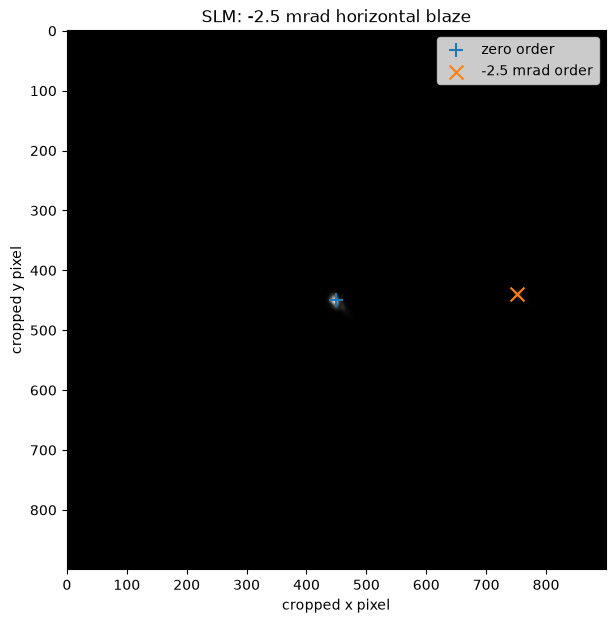

In [30]:
# Cell 16 — Apply -2.5 mrad x-blaze and locate the diffracted order
# BOTH SLM AND CAMERA ARE USED.

import time
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Generate reversed horizontal blaze
# ------------------------------------------------------------

theta_x_mrad_neg = -2.5

vector_x_neg_kxy = tuple(
    np.ravel(
        convert_vector(
            (theta_x_mrad_neg, 0.0),
            from_units="mrad",
            to_units="kxy",
            hardware=slm,
        )
    )
)

phase_blaze_x_neg = blaze(
    grid=slm,
    vector=vector_x_neg_kxy,
)

print("=== Reversed horizontal blaze ===")
print("Angle :", theta_x_mrad_neg, "mrad")
print("kxy   :", vector_x_neg_kxy)


# ------------------------------------------------------------
# 2. Write to SLM
# ------------------------------------------------------------

print("\nWriting blaze to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze_x_neg,
    settle=True,
)

print(f"SLM write completed in {time.perf_counter()-t0:.3f} s")


# ------------------------------------------------------------
# 3. Acquire image
# ------------------------------------------------------------

image_blaze_x_neg = cam.get_image(timeout_s=2)

print("\nCamera max              :", image_blaze_x_neg.max())
print("Saturated pixels        :", np.count_nonzero(image_blaze_x_neg == 255))


# ------------------------------------------------------------
# 4. Difference from flat phase
# ------------------------------------------------------------

diff_neg = (
    image_blaze_x_neg.astype(np.float32)
    - image_flat.astype(np.float32)
)

# Search in same annulus as before
search_neg = np.where(
    annulus,
    diff_neg,
    -np.inf,
)

neg_y, neg_x = np.unravel_index(
    np.argmax(search_neg),
    search_neg.shape,
)

dx_neg = neg_x - zero_x
dy_neg = neg_y - zero_y
r_neg = np.sqrt(dx_neg**2 + dy_neg**2)

print("\n=== Reversed first order ===")
print(f"x      = {neg_x}")
print(f"y      = {neg_y}")
print(f"dx     = {dx_neg:+d} pixels")
print(f"dy     = {dy_neg:+d} pixels")
print(f"radius = {r_neg:.1f} pixels")
print(f"shift  = {r_neg*camera_pitch_um:.1f} µm")


# ------------------------------------------------------------
# 5. Plot crop
# ------------------------------------------------------------

neg_crop = image_blaze_x_neg[y0:y1, x0:x1]

plt.figure(figsize=(9, 7))

plt.imshow(
    neg_crop,
    cmap="gray",
    origin="upper",
)

plt.scatter(
    zero_x - x0,
    zero_y - y0,
    marker="+",
    s=100,
    label="zero order",
)

plt.scatter(
    neg_x - x0,
    neg_y - y0,
    marker="x",
    s=100,
    label="-2.5 mrad order",
)

plt.xlabel("cropped x pixel")
plt.ylabel("cropped y pixel")
plt.title("SLM: -2.5 mrad horizontal blaze")
plt.legend()

plt.show()

=== Vertical blaze ===
Angle : 2.5 mrad
kxy   : (np.float64(0.0), np.float64(0.0025))

Writing blaze to SLM...
SLM write completed in 0.336 s

Camera max       : 159
Saturated pixels : 0

=== Vertical-blaze first order ===
x      = 3486
y      = 356
dx     = -13 pixels
dy     = -312 pixels
radius = 312.3 pixels
shift  = 749.4 µm


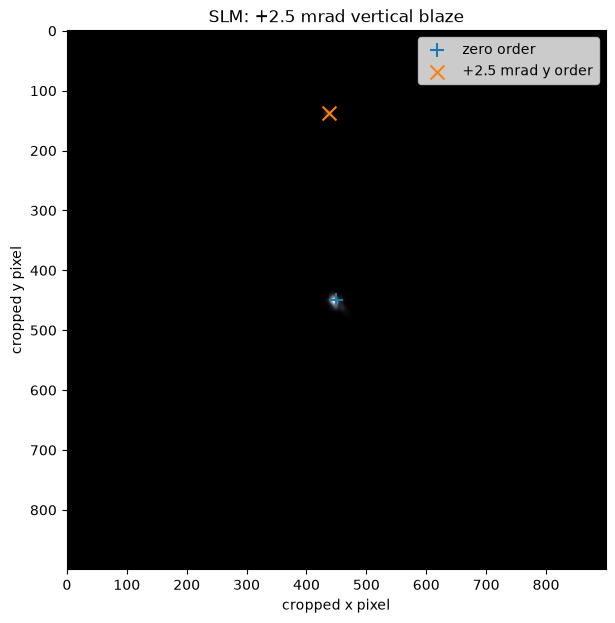

In [31]:
# Cell 17 — Apply +2.5 mrad y-blaze and locate the diffracted order
# BOTH SLM AND CAMERA ARE USED.

import time
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Generate vertical blaze
# ------------------------------------------------------------

theta_y_mrad = 2.5

vector_y_kxy = tuple(
    np.ravel(
        convert_vector(
            (0.0, theta_y_mrad),
            from_units="mrad",
            to_units="kxy",
            hardware=slm,
        )
    )
)

phase_blaze_y = blaze(
    grid=slm,
    vector=vector_y_kxy,
)

print("=== Vertical blaze ===")
print("Angle :", theta_y_mrad, "mrad")
print("kxy   :", vector_y_kxy)


# ------------------------------------------------------------
# 2. Write to SLM
# ------------------------------------------------------------

print("\nWriting blaze to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze_y,
    settle=True,
)

print(f"SLM write completed in {time.perf_counter()-t0:.3f} s")


# ------------------------------------------------------------
# 3. Acquire camera image
# ------------------------------------------------------------

image_blaze_y = cam.get_image(timeout_s=2)

print("\nCamera max       :", image_blaze_y.max())
print("Saturated pixels :", np.count_nonzero(image_blaze_y == 255))


# ------------------------------------------------------------
# 4. Compare against flat phase
# ------------------------------------------------------------

diff_y = (
    image_blaze_y.astype(np.float32)
    - image_flat.astype(np.float32)
)

# Reuse the annulus around the zero order from Cell 15.
search_y = np.where(
    annulus,
    diff_y,
    -np.inf,
)

order_y, order_x = np.unravel_index(
    np.argmax(search_y),
    search_y.shape,
)

dx_y = order_x - zero_x
dy_y = order_y - zero_y

r_y = np.sqrt(dx_y**2 + dy_y**2)

print("\n=== Vertical-blaze first order ===")
print(f"x      = {order_x}")
print(f"y      = {order_y}")
print(f"dx     = {dx_y:+d} pixels")
print(f"dy     = {dy_y:+d} pixels")
print(f"radius = {r_y:.1f} pixels")
print(f"shift  = {r_y*camera_pitch_um:.1f} µm")


# ------------------------------------------------------------
# 5. Plot crop around zero order
# ------------------------------------------------------------

y_crop = image_blaze_y[y0:y1, x0:x1]

plt.figure(figsize=(9, 7))

plt.imshow(
    y_crop,
    cmap="gray",
    origin="upper",
)

plt.scatter(
    zero_x - x0,
    zero_y - y0,
    marker="+",
    s=100,
    label="zero order",
)

plt.scatter(
    order_x - x0,
    order_y - y0,
    marker="x",
    s=100,
    label="+2.5 mrad y order",
)

plt.xlabel("cropped x pixel")
plt.ylabel("cropped y pixel")
plt.title("SLM: +2.5 mrad vertical blaze")
plt.legend()

plt.show()

In [34]:
# Cell 18 — Live camera viewer for beam centering
# Keeps BOTH existing hardware objects alive.
#
# The SLM is first returned to flat phase.
# Then a live camera viewer is opened in Jupyter.

print("Returning SLM to flat phase...")

slm.set_phase(
    None,
    settle=True,
)

print("Flat phase active.")
print("Launching camera viewer...")

cam.live(
    activate=True,
    widgets=True,
    cmap="gray",
    min=0,
    max=220,
    scale=0.25,
    crosshair=True,
)

print("\nCamera sensor center:")
print("x =", cam.shape[1] / 2)
print("y =", cam.shape[0] / 2)

print("\nClick the 'Live' button in the viewer to start continuous acquisition.")

Returning SLM to flat phase...
Flat phase active.
Launching camera viewer...


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x05^\x00\x00\x03\x96\x08\x06\x00\x00\x00\x17\xd6\x89…


Camera sensor center:
x = 2748.0
y = 1836.0

Click the 'Live' button in the viewer to start continuous acquisition.


Acquiring aligned flat-phase image...

=== New alignment ===
Zero order    : x = 2746, y = 1842
Sensor center : x = 2748.0, y = 1836.0

Offset from center:
dx = -2.0 pixels
dy = +6.0 pixels

Max              : 124
Saturated pixels : 0
Acquisition time : 0.357 s


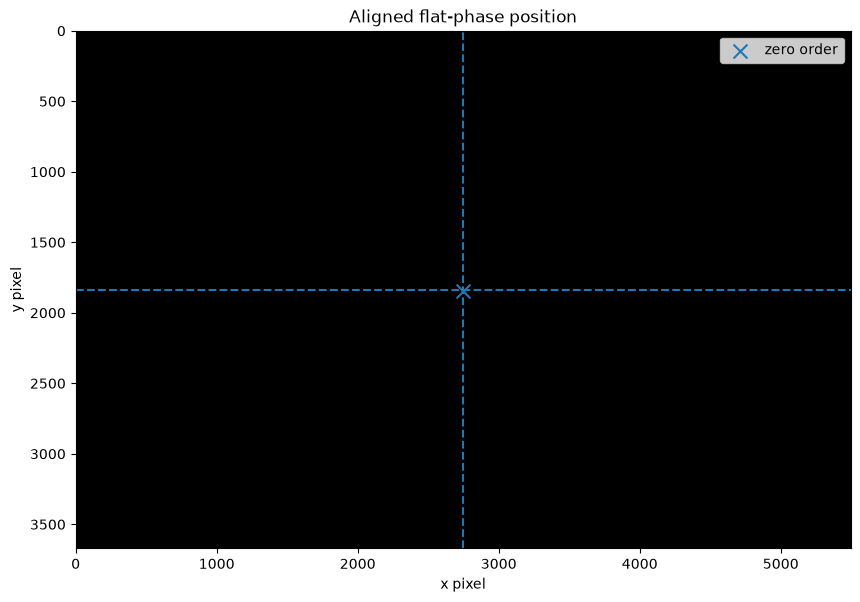

In [37]:
# Cell 19 — Acquire a fresh flat-phase image after alignment

import time
import numpy as np
import matplotlib.pyplot as plt

# Ensure flat phase
slm.set_phase(None, settle=True)

print("Acquiring aligned flat-phase image...")

t0 = time.perf_counter()

image_flat_aligned = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

# Brightest point
zero_y_new, zero_x_new = np.unravel_index(
    np.argmax(image_flat_aligned),
    image_flat_aligned.shape
)

# Sensor center
sensor_center_x = cam.shape[1] / 2
sensor_center_y = cam.shape[0] / 2

print("\n=== New alignment ===")
print(f"Zero order    : x = {zero_x_new}, y = {zero_y_new}")
print(f"Sensor center : x = {sensor_center_x:.1f}, y = {sensor_center_y:.1f}")

print()
print(f"Offset from center:")
print(f"dx = {zero_x_new - sensor_center_x:+.1f} pixels")
print(f"dy = {zero_y_new - sensor_center_y:+.1f} pixels")

print()
print("Max              :", image_flat_aligned.max())
print("Saturated pixels :", np.count_nonzero(image_flat_aligned == 255))
print(f"Acquisition time : {dt:.3f} s")

plt.figure(figsize=(10, 7))

plt.imshow(
    image_flat_aligned,
    cmap="gray",
    origin="upper",
)

plt.axvline(sensor_center_x, linestyle="--")
plt.axhline(sensor_center_y, linestyle="--")

plt.scatter(
    zero_x_new,
    zero_y_new,
    marker="x",
    s=100,
    label="zero order",
)

plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Aligned flat-phase position")
plt.legend()

plt.show()

In [38]:
# Cell 20 — Inspect hardware ROI/WOI constraints
# NO camera geometry is changed in this cell.

print("=== Allied Vision ROI constraints ===\n")

features = [
    ("Width",   cam.cam.Width),
    ("Height",  cam.cam.Height),
    ("OffsetX", cam.cam.OffsetX),
    ("OffsetY", cam.cam.OffsetY),
]

for name, feature in features:

    print(name)

    print("  Current   :", feature.get())
    print("  Range     :", feature.get_range())

    try:
        print("  Increment :", feature.get_increment())
    except Exception:
        print("  Increment : unavailable")

    print()

print("Current slmsuite WOI:", cam.woi)

print("\n=== Final optical center ===")
print("Zero order : x =", zero_x_new, ", y =", zero_y_new)
print("Sensor     : x =", cam.shape[1] / 2,
      ", y =", cam.shape[0] / 2)

=== Allied Vision ROI constraints ===

Width
  Current   : 5496
  Range     : (8, 5496)
  Increment : 8

Height
  Current   : 3672
  Range     : (8, 3672)
  Increment : 2

OffsetX
  Current   : 0
  Range     : (0, 0)
  Increment : 2

OffsetY
  Current   : 0
  Range     : (0, 0)
  Increment : 2

Current slmsuite WOI: (0, 5496, 0, 3672)

=== Final optical center ===
Zero order : x = 2746 , y = 1842
Sensor     : x = 2748.0 , y = 1836.0


Setting camera WOI to:
(1948, 1600, 1036, 1600)

=== Hardware ROI after setting ===
OffsetX : 1948
OffsetY : 1036
Width   : 1600
Height  : 1600
cam.woi : (1948, 1600, 1036, 1600)

Acquiring ROI frame...

=== ROI image ===
Returned shape   : (1600, 1600)
cam.shape        : (3672, 5496)
Max              : 0
Saturated pixels : 0
Acquisition time : 0.194 s

Zero order in ROI:
x = 0
y = 0


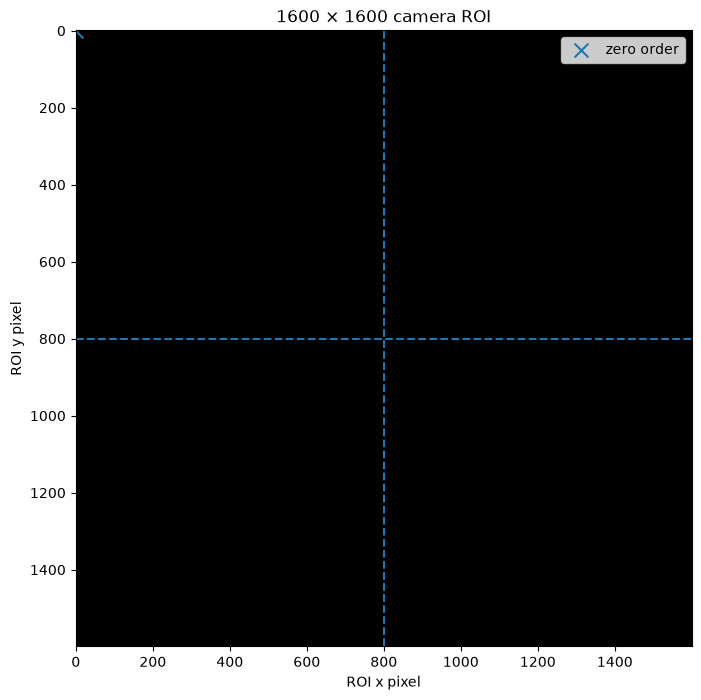

In [39]:
# Cell 21 — Set centered 1600 x 1600 hardware ROI
# THIS CHANGES THE CAMERA HARDWARE ROI.

import time
import numpy as np
import matplotlib.pyplot as plt

# Stop any live viewer before changing camera geometry.
cam.live(activate=False)

# ROI in slmsuite convention:
# (x_offset, width, y_offset, height)
ROI_X = 1948
ROI_W = 1600

ROI_Y = 1036
ROI_H = 1600

roi = (ROI_X, ROI_W, ROI_Y, ROI_H)

print("Setting camera WOI to:")
print(roi)

cam.set_woi(roi)

print("\n=== Hardware ROI after setting ===")
print("OffsetX :", cam.cam.OffsetX.get())
print("OffsetY :", cam.cam.OffsetY.get())
print("Width   :", cam.cam.Width.get())
print("Height  :", cam.cam.Height.get())
print("cam.woi :", cam.woi)

print("\nAcquiring ROI frame...")

t0 = time.perf_counter()

image_roi = cam.get_image(timeout_s=2)

dt = time.perf_counter() - t0

print("\n=== ROI image ===")
print("Returned shape   :", image_roi.shape)
print("cam.shape        :", cam.shape)
print("Max              :", image_roi.max())
print("Saturated pixels :", np.count_nonzero(image_roi == 255))
print(f"Acquisition time : {dt:.3f} s")

# Locate zero order inside the new ROI.
roi_y_peak, roi_x_peak = np.unravel_index(
    np.argmax(image_roi),
    image_roi.shape
)

print("\nZero order in ROI:")
print("x =", roi_x_peak)
print("y =", roi_y_peak)

plt.figure(figsize=(8, 8))

plt.imshow(
    image_roi,
    cmap="gray",
    origin="upper",
)

plt.axvline(ROI_W / 2, linestyle="--")
plt.axhline(ROI_H / 2, linestyle="--")

plt.scatter(
    roi_x_peak,
    roi_y_peak,
    marker="x",
    s=100,
    label="zero order",
)

plt.xlabel("ROI x pixel")
plt.ylabel("ROI y pixel")
plt.title("1600 × 1600 camera ROI")
plt.legend()

plt.show()

In [40]:
# Cell 22 — Diagnose blank ROI acquisition
# NO hardware settings are changed.

import time
import numpy as np

print("=== Current hardware ROI ===")
print("OffsetX :", cam.cam.OffsetX.get())
print("OffsetY :", cam.cam.OffsetY.get())
print("Width   :", cam.cam.Width.get())
print("Height  :", cam.cam.Height.get())
print("WOI     :", cam.woi)

print("\nWaiting briefly after ROI change...")
time.sleep(1.0)

print("\n=== Consecutive ROI frames ===")

roi_test_frames = []

for i in range(5):

    t0 = time.perf_counter()

    # transform=False gives us the raw hardware-oriented frame.
    img = cam.get_image(
        timeout_s=2,
        transform=False,
    )

    dt = time.perf_counter() - t0

    roi_test_frames.append(img)

    print(
        f"Frame {i+1}: "
        f"shape={img.shape}, "
        f"min={img.min()}, "
        f"max={img.max()}, "
        f"sum={img.sum()}, "
        f"time={dt:.3f} s"
    )

    time.sleep(0.2)

=== Current hardware ROI ===
OffsetX : 1948
OffsetY : 1036
Width   : 1600
Height  : 1600
WOI     : (1948, 1600, 1036, 1600)

Waiting briefly after ROI change...

=== Consecutive ROI frames ===
Frame 1: shape=(1600, 1600), min=0, max=0, sum=0, time=0.208 s
Frame 2: shape=(1600, 1600), min=0, max=0, sum=0, time=0.208 s
Frame 3: shape=(1600, 1600), min=0, max=0, sum=0, time=0.207 s
Frame 4: shape=(1600, 1600), min=0, max=0, sum=0, time=0.206 s
Frame 5: shape=(1600, 1600), min=0, max=0, sum=0, time=0.207 s


Restoring full camera sensor...

=== Restored hardware geometry ===
OffsetX : 0
OffsetY : 0
Width   : 5496
Height  : 3672
cam.woi : (0, 5496, 0, 3672)

Acquiring full-frame image...

=== Restored image ===
Shape : (3672, 5496)
Min   : 0
Max   : 32
Sum   : 32
Time  : 0.384 s

Peak position:
x = 3923
y = 3671


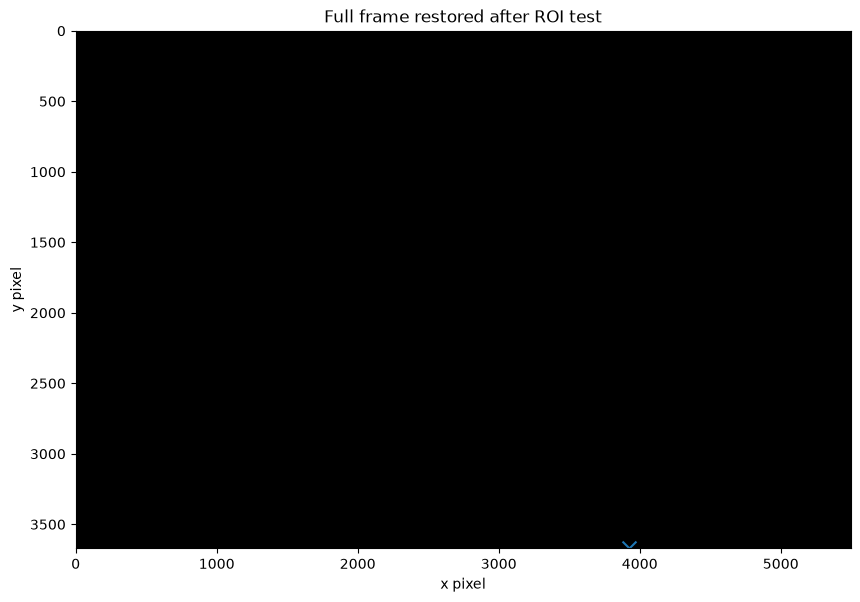

In [42]:
# Cell 23 — Restore full-frame acquisition
# THIS CHANGES THE CAMERA ROI BACK TO FULL SENSOR.

import time
import numpy as np
import matplotlib.pyplot as plt

print("Restoring full camera sensor...")

cam.set_woi(None)

print("\n=== Restored hardware geometry ===")
print("OffsetX :", cam.cam.OffsetX.get())
print("OffsetY :", cam.cam.OffsetY.get())
print("Width   :", cam.cam.Width.get())
print("Height  :", cam.cam.Height.get())
print("cam.woi :", cam.woi)

# Give the camera a moment after geometry change.
time.sleep(0.5)

print("\nAcquiring full-frame image...")

t0 = time.perf_counter()

image_full_restored = cam.get_image(
    timeout_s=2,
    transform=False,
)

dt = time.perf_counter() - t0

print("\n=== Restored image ===")
print("Shape :", image_full_restored.shape)
print("Min   :", image_full_restored.min())
print("Max   :", image_full_restored.max())
print("Sum   :", image_full_restored.sum())
print(f"Time  : {dt:.3f} s")

# Locate beam
peak_y, peak_x = np.unravel_index(
    np.argmax(image_full_restored),
    image_full_restored.shape
)

print("\nPeak position:")
print("x =", peak_x)
print("y =", peak_y)

plt.figure(figsize=(10, 7))
plt.imshow(image_full_restored, cmap="gray", origin="upper")
plt.scatter(peak_x, peak_y, marker="x", s=100)
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Full frame restored after ROI test")
plt.show()

In [43]:
# Cell 24 — Check whether camera signal responds to increased optical power
# NO ROI change, NO camera restart, NO exposure change.

import time
import numpy as np

print("=== Current camera state ===")
print("Width    :", cam.cam.Width.get())
print("Height   :", cam.cam.Height.get())
print("OffsetX  :", cam.cam.OffsetX.get())
print("OffsetY  :", cam.cam.OffsetY.get())
print("Exposure :", cam.get_exposure() * 1e6, "us")

print("\nAcquire 3 full-frame images after increasing laser power...\n")

for i in range(3):

    t0 = time.perf_counter()

    img_test = cam.get_image(
        timeout_s=2,
        transform=False,
    )

    dt = time.perf_counter() - t0

    peak_y, peak_x = np.unravel_index(
        np.argmax(img_test),
        img_test.shape
    )

    print(f"Frame {i+1}")
    print("  shape       :", img_test.shape)
    print("  min         :", img_test.min())
    print("  max         :", img_test.max())
    print("  sum         :", img_test.sum())
    print("  nonzero px  :", np.count_nonzero(img_test))
    print("  peak x,y    :", peak_x, peak_y)
    print(f"  time        : {dt:.3f} s")
    print()

    time.sleep(0.2)

=== Current camera state ===
Width    : 5496
Height   : 3672
OffsetX  : 0
OffsetY  : 0
Exposure : 194.681 us

Acquire 3 full-frame images after increasing laser power...

Frame 1
  shape       : (3672, 5496)
  min         : 0
  max         : 255
  sum         : 820911
  nonzero px  : 28950
  peak x,y    : 2751 1817
  time        : 0.390 s

Frame 2
  shape       : (3672, 5496)
  min         : 0
  max         : 255
  sum         : 851956
  nonzero px  : 29132
  peak x,y    : 2755 1815
  time        : 0.391 s

Frame 3
  shape       : (3672, 5496)
  min         : 0
  max         : 255
  sum         : 839973
  nonzero px  : 28853
  peak x,y    : 2753 1817
  time        : 0.394 s



In [51]:
# Cell 25 — Retry 1600 x 1600 ROI now that camera signal is healthy

import time
import numpy as np

# First confirm full-frame signal immediately before ROI change.
print("=== Full-frame check before ROI ===")

img_before_roi = cam.get_image(
    timeout_s=2,
    transform=False,
)

print("Shape        :", img_before_roi.shape)
print("Max          :", img_before_roi.max())
print("Sum          :", img_before_roi.sum())
print("Nonzero      :", np.count_nonzero(img_before_roi))

peak_y, peak_x = np.unravel_index(
    np.argmax(img_before_roi),
    img_before_roi.shape
)

print("Peak x,y     :", peak_x, peak_y)


# ------------------------------------------------------------
# Set same centered ROI
# ------------------------------------------------------------

roi = (1948, 1600, 1036, 1600)

print("\nSetting ROI:", roi)

cam.set_woi(roi)

time.sleep(0.5)

print("\n=== Hardware ROI ===")
print("OffsetX :", cam.cam.OffsetX.get())
print("OffsetY :", cam.cam.OffsetY.get())
print("Width   :", cam.cam.Width.get())
print("Height  :", cam.cam.Height.get())
print("WOI     :", cam.woi)


# ------------------------------------------------------------
# Acquire three ROI frames
# ------------------------------------------------------------

print("\n=== ROI frames ===")

for i in range(3):

    t0 = time.perf_counter()

    img_roi_test = cam.get_image(
        timeout_s=2,
        transform=False,
    )

    dt = time.perf_counter() - t0

    peak_y_roi, peak_x_roi = np.unravel_index(
        np.argmax(img_roi_test),
        img_roi_test.shape
    )

    print(
        f"Frame {i+1}: "
        f"shape={img_roi_test.shape}, "
        f"max={img_roi_test.max()}, "
        f"sum={img_roi_test.sum()}, "
        f"nonzero={np.count_nonzero(img_roi_test)}, "
        f"peak=({peak_x_roi},{peak_y_roi}), "
        f"time={dt:.3f} s"
    )

    time.sleep(0.2)

=== Full-frame check before ROI ===
Shape        : (1600, 1600)
Max          : 182
Sum          : 73880
Nonzero      : 3836
Peak x,y     : 809 803

Setting ROI: (1948, 1600, 1036, 1600)

=== Hardware ROI ===
OffsetX : 1948
OffsetY : 1036
Width   : 1600
Height  : 1600
WOI     : (1948, 1600, 1036, 1600)

=== ROI frames ===
Frame 1: shape=(1600, 1600), max=176, sum=73996, nonzero=3895, peak=(808,802), time=0.198 s
Frame 2: shape=(1600, 1600), max=174, sum=73948, nonzero=3808, peak=(809,802), time=0.200 s
Frame 3: shape=(1600, 1600), max=190, sum=74096, nonzero=3730, peak=(809,802), time=0.197 s
